In [11]:
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import disk 
from skimage import io
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

In [12]:
# From https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html
def plot_comparison(original, filtered, filter_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')
    io.show()

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


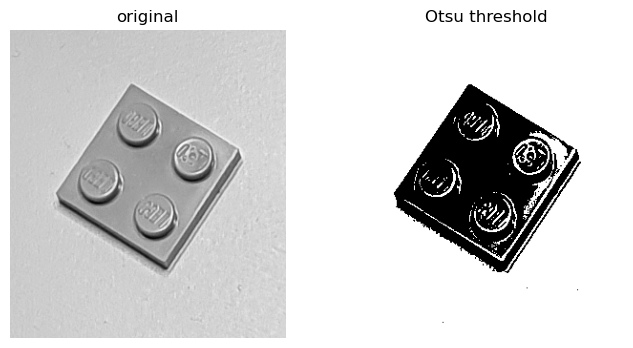

In [13]:
im_org = io.imread("../data/lego_5.png", as_gray=True)
T = threshold_otsu(im_org)
bin_img = im_org > T
plot_comparison(im_org, bin_img, "Otsu threshold")

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


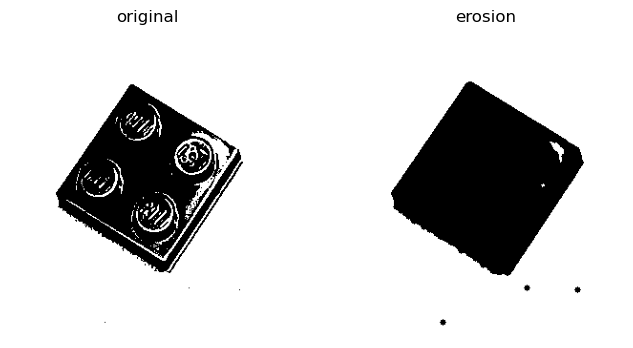

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


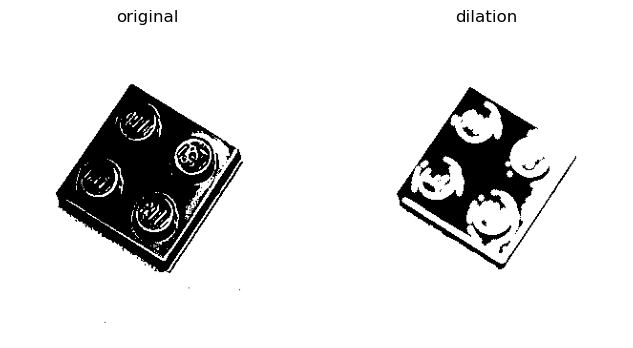

In [14]:
footprint = disk(3)
# Check the size and shape of the structuring element
# remove small objects
eroded = erosion(bin_img, footprint)
plot_comparison(bin_img, eroded, 'erosion')
# make objects larger
dilated = dilation(bin_img, footprint)
plot_comparison(bin_img, dilated, 'dilation')

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


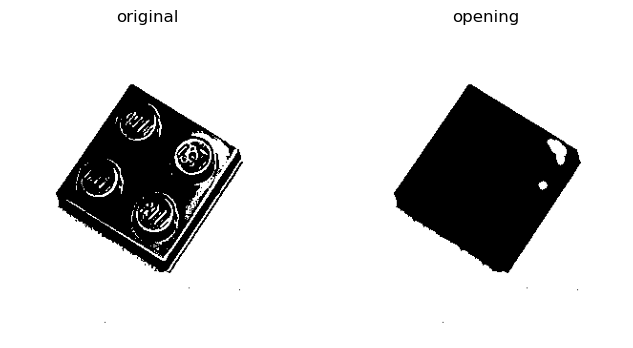

In [15]:
footprint = disk(3)
opened = opening(bin_img, footprint)
plot_comparison(bin_img, opened, 'opening')

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


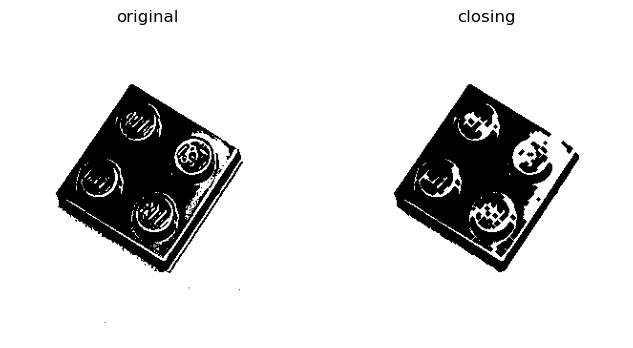

In [16]:
footprint = disk(2)
closed = closing(bin_img, footprint)
plot_comparison(bin_img, closed, 'closing')

In [17]:
def compute_outline(bin_img):
    """
    Computes the outline of a binary image
    """
    footprint = disk(1)
    dilated = dilation(bin_img, footprint)
    outline = np.logical_xor(dilated, bin_img)
    return outline

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


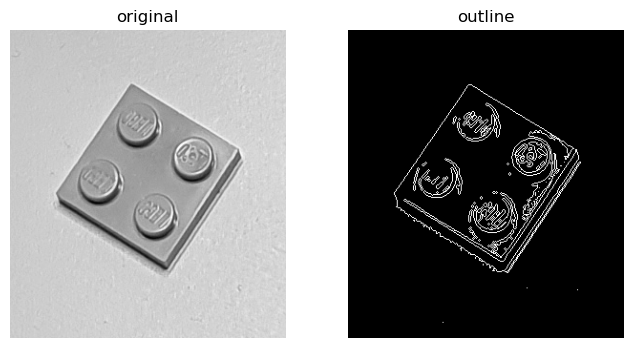

In [19]:
import numpy as np
outline_img = compute_outline(bin_img)
plot_comparison(im_org, outline_img, "outline")

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


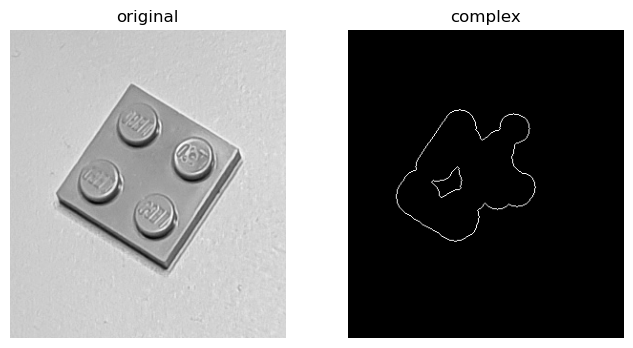

In [22]:
img_open = opening(bin_img, disk(1))
img_closed = closing(img_open, disk(15))
outline = compute_outline(img_closed)
plot_comparison(im_org, outline, "complex")

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


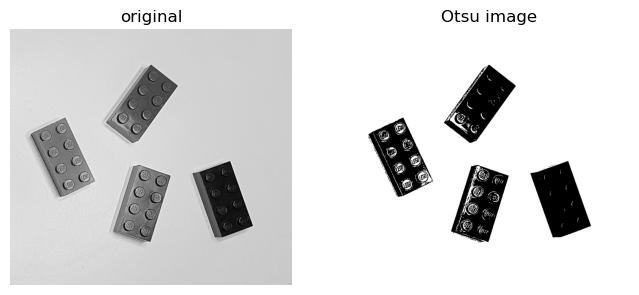

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


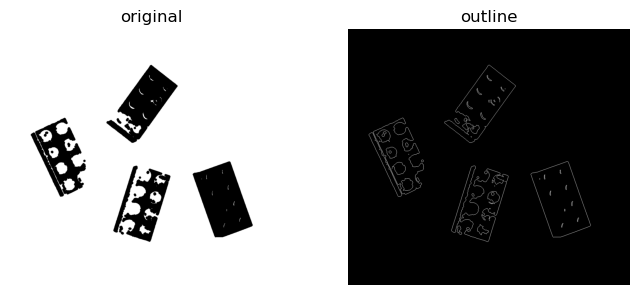

In [26]:
img_7 = io.imread("../data/lego_7.png", as_gray=True)
T = threshold_otsu(img_7)
bin_img_7 = img_7 > T
plot_comparison(img_7, bin_img_7, "Otsu image")
bin_img_7 = closing(bin_img_7, disk(4))
outline = compute_outline(bin_img_7)
plot_comparison(bin_img_7, outline, "outline")

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


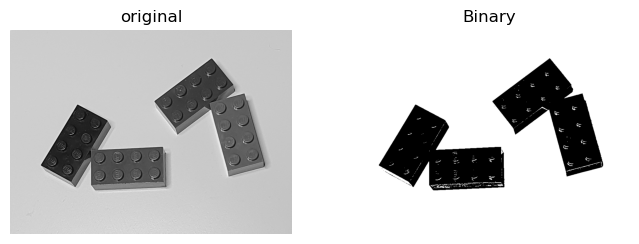

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


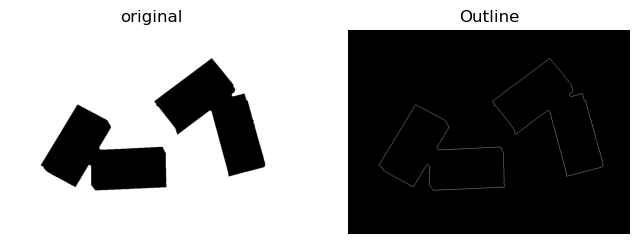

In [ ]:
img_9 = io.imread("../data/lego_9.png", as_gray=True)
T = threshold_otsu(img_9)
bin_img_9 = img_9 > T
plot_comparison(img_9, bin_img_9, "Binary")
# fill holes
bin_img_9 = opening(bin_img_9, disk(5))
outline = compute_outline(bin_img_9)
plot_comparison(bin_img_9, outline, "Outline")

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


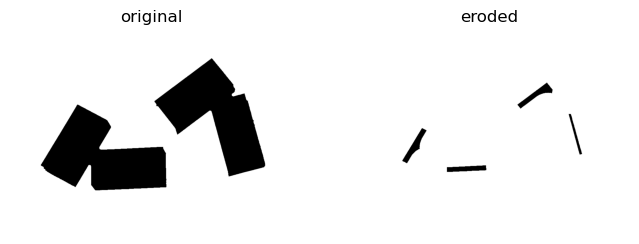

In [42]:
eroded = dilation(bin_img_9, disk(60))
plot_comparison(bin_img_9, eroded, "eroded")

/tmp/ipykernel_5663/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


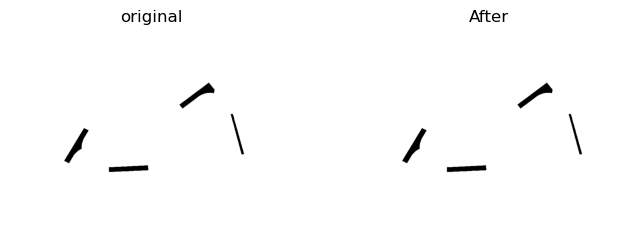

In [45]:
erode_back = erosion(eroded, disk(100))
plot_comparison(eroded, eroded, "After")